# Análisis de churn

Predecir el abandono de clientes de una telco iraní, siguiendo CRISP-DM.

## 1. Comprensión del negocio

Retener sale más barato que captar: queremos anticipar quién se va. Es clasificación binaria desbalanceada (~16% churn), así que miramos recall y F1 de churn, no accuracy.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

## 2. Comprensión de los datos

Cargamos el CSV y normalizamos los nombres de columna.

In [2]:
df = pd.read_csv("data/Iran_Customer_Churn.csv")
df.columns = df.columns.str.replace(r"\s+", " ", regex=True).str.strip()
df.head()

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value,Churn
0,8,0,38,0,4370,71,5,17,3,1,1,30,197.640,0
1,0,0,39,0,318,5,7,4,2,1,2,25,46.035,0
2,10,0,37,0,2453,60,359,24,3,1,1,30,1536.520,0
3,10,0,38,0,4198,66,1,35,1,1,1,15,240.020,0
4,3,0,38,0,2393,58,2,33,1,1,1,15,145.805,0


Integridad: forma, nulos y duplicados.

- **Para qué**: chequear que el dataset esté sano antes de analizarlo (tamaño, faltantes, filas repetidas, tipos).
- **Qué espero**: pocos o ningún nulo y confirmar que las 13 variables más el target sean numéricas; los duplicados me dirán si hay que limpiar.
- **Qué dio**: 3150 filas x 14 columnas, 0 nulos, 300 duplicados, todo numérico (int salvo Customer Value).
- **Qué concluyo**: no hace falta imputar. Los 300 duplicados los dejo porque con estos atributos dos clientes pueden compartir valores sin ser la misma persona (no hay id), no los trato como error.

In [3]:
print("shape:", df.shape)
print("nulos:", int(df.isnull().sum().sum()))
print("duplicados:", int(df.duplicated().sum()))
df.dtypes.astype(str)

shape: (3150, 14)
nulos: 0
duplicados: 300


Call Failure                 int64
Complains                    int64
Subscription Length          int64
Charge Amount                int64
Seconds of Use               int64
Frequency of use             int64
Frequency of SMS             int64
Distinct Called Numbers      int64
Age Group                    int64
Tariff Plan                  int64
Status                       int64
Age                          int64
Customer Value             float64
Churn                        int64
dtype: object

Estadística descriptiva de cada variable.

- **Para qué**: ver rangos, escalas y asimetrías de cada atributo de un vistazo.
- **Qué espero**: escalas muy distintas entre variables (segundos de uso vs. quejas) y colas largas en las de consumo.
- **Qué dio**: Seconds of Use llega a 17090 y Customer Value a 2165 mientras Complains es 0/1; media de Churn 0.157 confirma el ~16% de abandono.
- **Qué concluyo**: las escalas son incomparables, así que voy a tener que estandarizar antes de modelos sensibles a distancia (KNN, LogReg).

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Call Failure,3150.0,7.627937,7.263886,0.0,1.00000,6.00,12.00000,36.00
Complains,3150.0,0.076508,0.265851,0.0,0.00000,0.00,0.00000,1.00
Subscription Length,3150.0,32.541905,8.573482,3.0,30.00000,35.00,38.00000,47.00
Charge Amount,3150.0,0.942857,1.521072,0.0,0.00000,0.00,1.00000,10.00
Seconds of Use,3150.0,4472.459683,4197.908687,0.0,1391.25000,2990.00,6478.25000,17090.00
Frequency of use,3150.0,69.460635,57.413308,0.0,27.00000,54.00,95.00000,255.00
Frequency of SMS,3150.0,73.174921,112.237560,0.0,6.00000,21.00,87.00000,522.00
Distinct Called Numbers,3150.0,23.509841,17.217337,0.0,10.00000,21.00,34.00000,97.00
Age Group,3150.0,2.826032,0.892555,1.0,2.00000,3.00,3.00000,5.00
Tariff Plan,3150.0,1.077778,0.267864,1.0,1.00000,1.00,1.00000,2.00


### Balance del target

Countplot del churn.

- **Para qué**: medir el desbalance de clases, que define qué métrica vale y si conviene balancear.
- **Qué espero**: una clase churn minoritaria, en torno al 15-20% como es típico en telco; lo bastante chica como para que la accuracy quede inflada y no sirva de criterio.
- **Qué dio**: ver gráfico abajo.

/var/folders/pp/2w01y9pd6px1lfx6rs9vs5p00000gp/T/ipykernel_99774/2138999497.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x="Churn", data=df, palette=["#4c72b0", "#c44e52"])
/var/folders/pp/2w01y9pd6px1lfx6rs9vs5p00000gp/T/ipykernel_99774/2138999497.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["No churn", "Churn"])


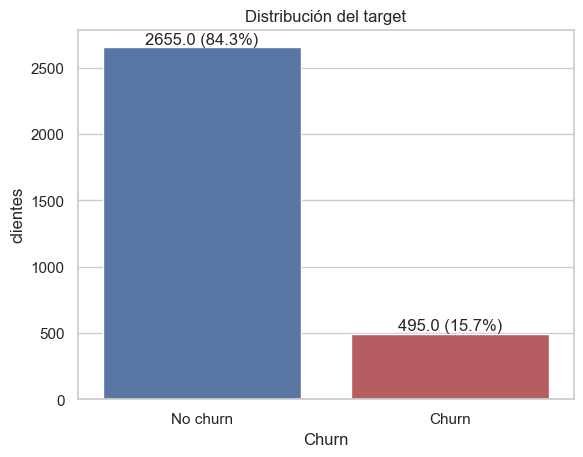

In [5]:
ax = sns.countplot(x="Churn", data=df, palette=["#4c72b0", "#c44e52"])
total = len(df)
for p in ax.patches:
    ax.annotate(f"{p.get_height()} ({p.get_height()/total:.1%})",
                (p.get_x() + p.get_width()/2, p.get_height()), ha="center", va="bottom")
ax.set_xticklabels(["No churn", "Churn"])
ax.set_title("Distribución del target")
ax.set_ylabel("clientes")
plt.show()

**Qué dio**: 2655 (84.3%) se quedan y 495 (15.7%) se van. **Qué concluyo**: dataset desbalanceado, así que me voy a guiar por recall y F1 de la clase churn y no por accuracy, y voy a usar `class_weight="balanced"` en los modelos que lo permitan.

### Distribución de las variables continuas por churn

Histogramas de densidad de cada continua, separados por churn.

- **Para qué**: ver cómo se distribuye cada variable de consumo y si su forma cambia entre los que se van y los que se quedan.
- **Qué espero**: que en las variables de uso (segundos, frecuencia, customer value) los churners se concentren en valores bajos.
- **Qué dio**: ver gráfico abajo.

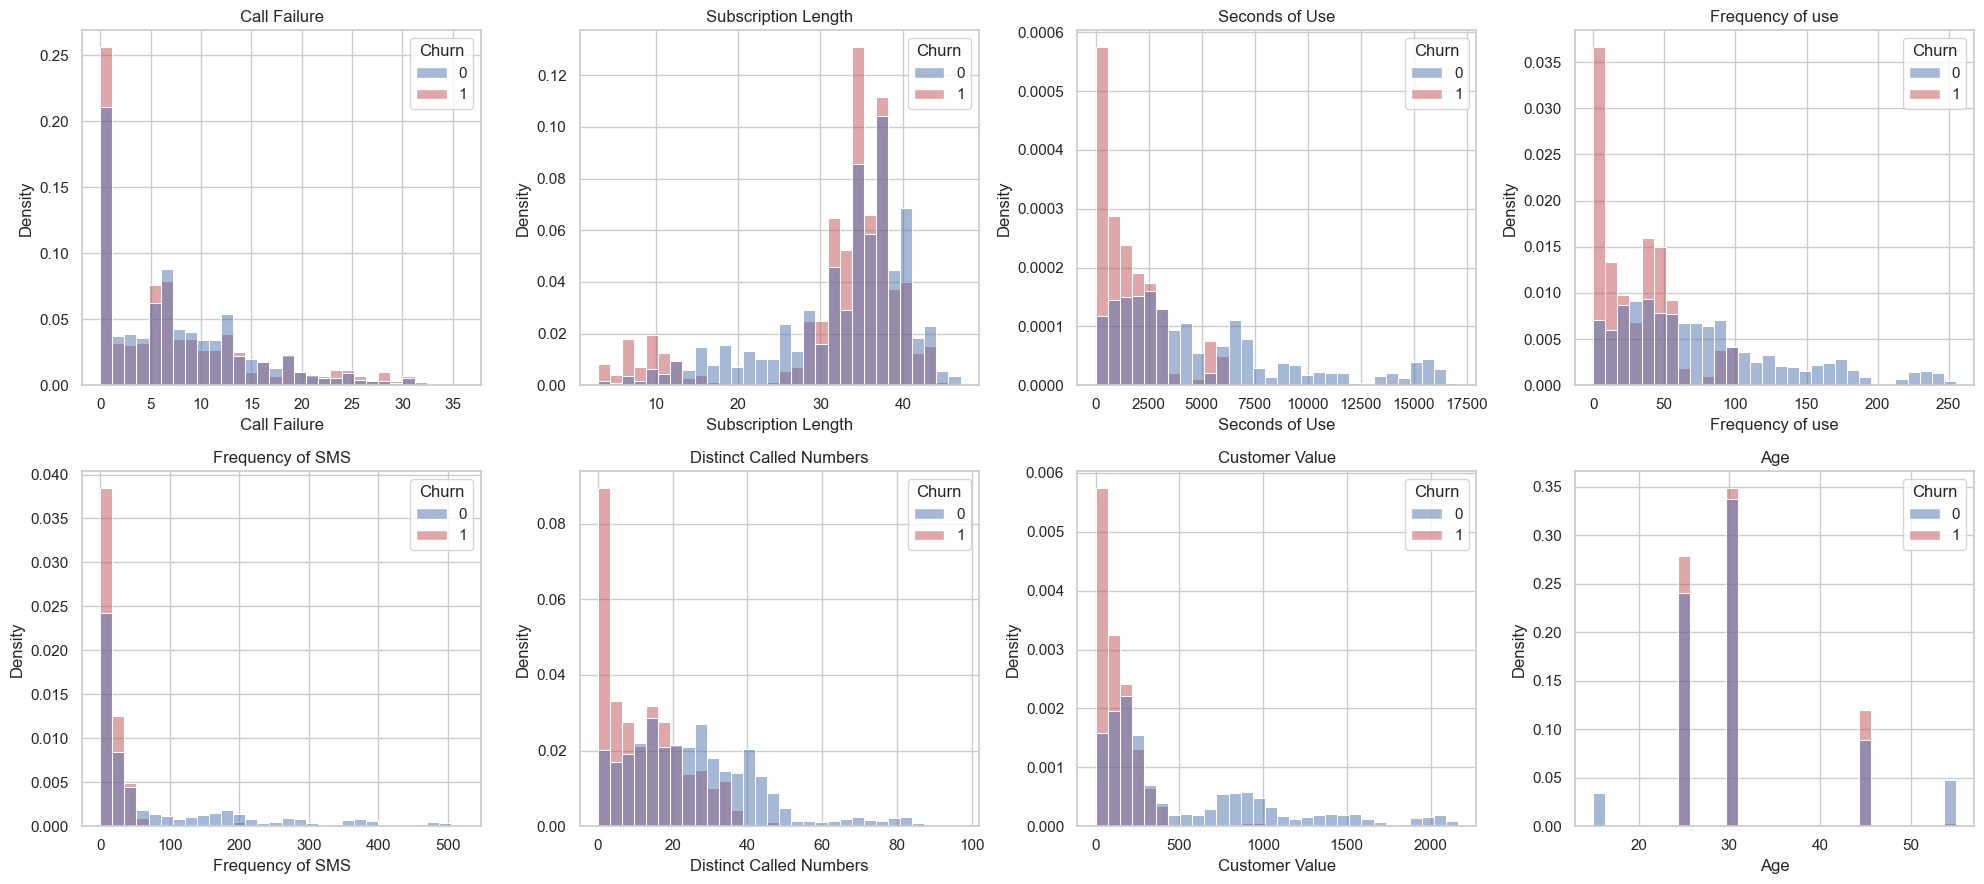

In [6]:
continuas = ["Call Failure", "Subscription Length", "Seconds of Use", "Frequency of use",
             "Frequency of SMS", "Distinct Called Numbers", "Customer Value", "Age"]
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
for ax, c in zip(axes.ravel(), continuas):
    sns.histplot(data=df, x=c, hue="Churn", bins=30, stat="density",
                 common_norm=False, palette=["#4c72b0", "#c44e52"], ax=ax, alpha=0.5)
    ax.set_title(c)
plt.tight_layout()
plt.show()

**Qué dio**: los churners se amontonan en la izquierda (uso bajo) en Seconds of Use, Frequency of use, Customer Value y Distinct Called Numbers; en Subscription Length y Age casi no se separan. **Qué concluyo**: el abandono está atado al uso bajo, no a la antigüedad ni a la edad.

### Boxplots por churn

Boxplots de cada continua contra churn.

- **Para qué**: confirmar el patrón de los histogramas con medianas y dispersión, y de paso ver outliers.
- **Qué espero**: mediana más baja en el grupo churn para las variables de uso.
- **Qué dio**: ver gráfico abajo.

/var/folders/pp/2w01y9pd6px1lfx6rs9vs5p00000gp/T/ipykernel_99774/2202985652.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Churn", y=c, palette=["#4c72b0", "#c44e52"], ax=ax)
/var/folders/pp/2w01y9pd6px1lfx6rs9vs5p00000gp/T/ipykernel_99774/2202985652.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["no", "sí"])
/var/folders/pp/2w01y9pd6px1lfx6rs9vs5p00000gp/T/ipykernel_99774/2202985652.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Churn", y=c, palette=["#4c72b0", "#c44e52"], ax=ax)
/var/folders/pp/2w01y9pd6px1lfx6rs9vs5p00000gp/T/ipykernel_99774/2202

/var/folders/pp/2w01y9pd6px1lfx6rs9vs5p00000gp/T/ipykernel_99774/2202985652.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Churn", y=c, palette=["#4c72b0", "#c44e52"], ax=ax)
/var/folders/pp/2w01y9pd6px1lfx6rs9vs5p00000gp/T/ipykernel_99774/2202985652.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["no", "sí"])


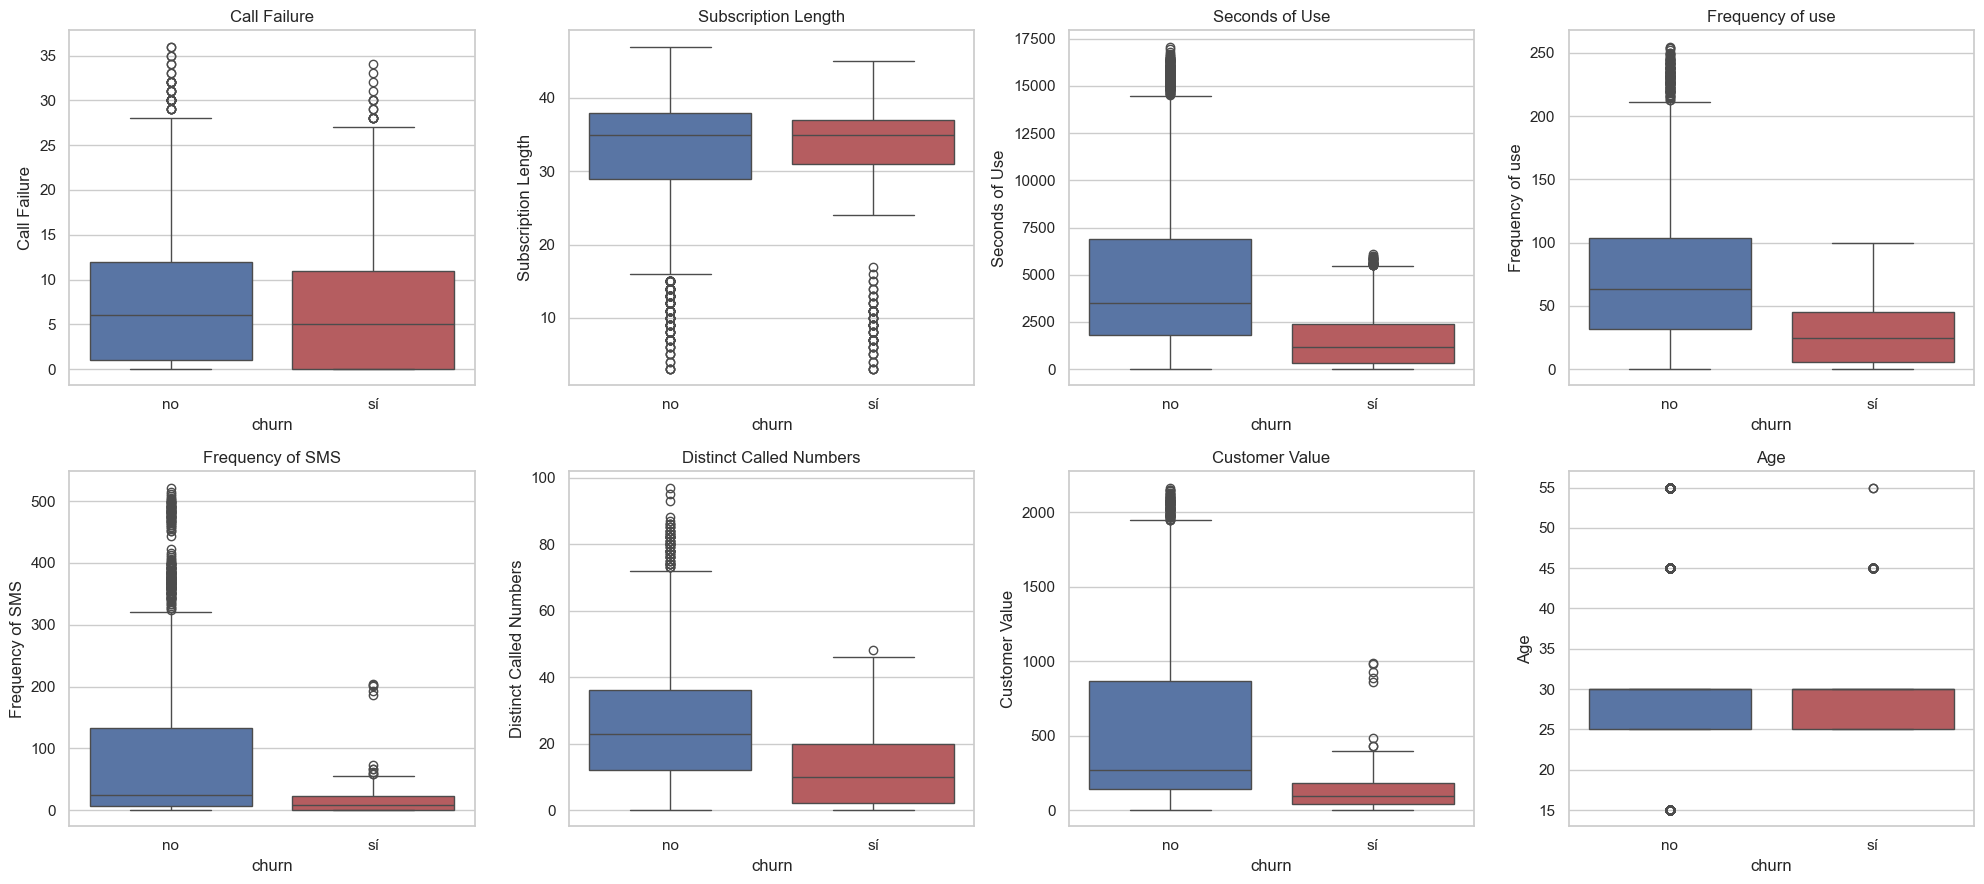

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
for ax, c in zip(axes.ravel(), continuas):
    sns.boxplot(data=df, x="Churn", y=c, palette=["#4c72b0", "#c44e52"], ax=ax)
    ax.set_xticklabels(["no", "sí"])
    ax.set_title(c)
    ax.set_xlabel("churn")
plt.tight_layout()
plt.show()

**Qué dio**: confirma los histogramas; la mediana de uso del grupo churn está claramente por debajo. **Qué concluyo**: el patrón de uso bajo es robusto, no un artefacto de la forma de la distribución.

### Variables binarias y ordinales

Tasa de churn por categoría (crosstab normalizado por fila).

- **Para qué**: ver, dentro de cada categoría de las variables discretas, qué proporción se va.
- **Qué espero**: que tener una queja (Complains=1) y estar inactivo (Status=2) disparen la tasa de churn.
- **Qué dio**: ver gráfico abajo.

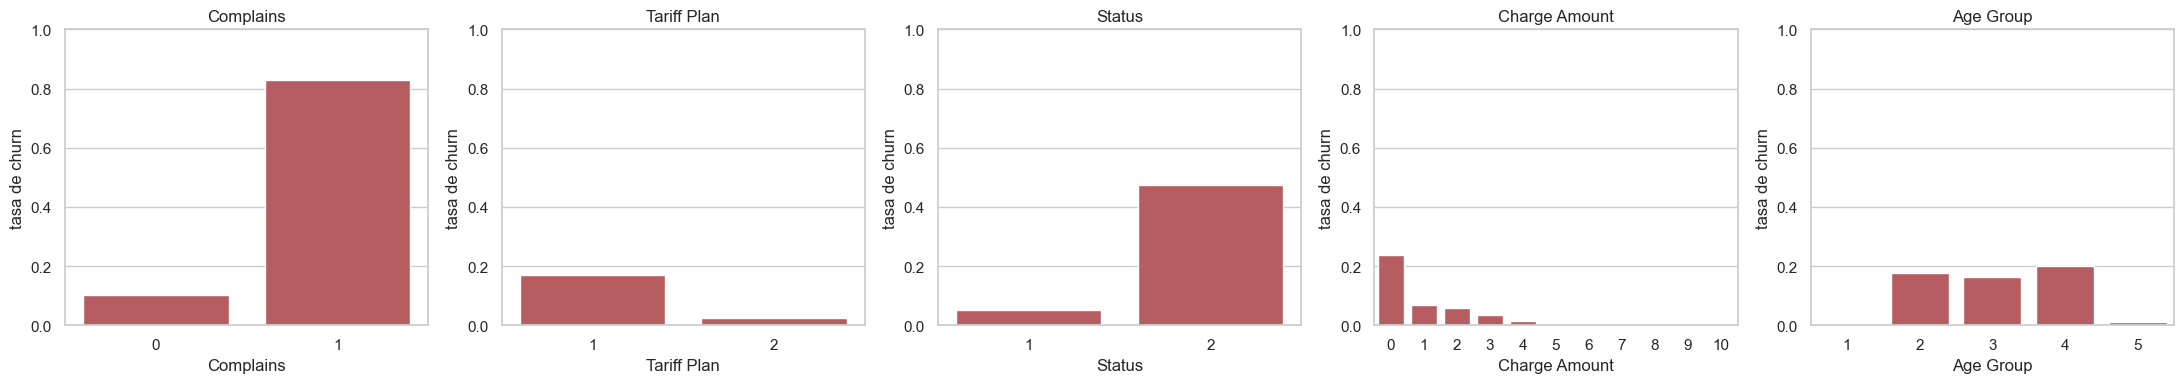

In [8]:
discretas = ["Complains", "Tariff Plan", "Status", "Charge Amount", "Age Group"]
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, c in zip(axes, discretas):
    tab = pd.crosstab(df[c], df["Churn"], normalize="index")[1]
    sns.barplot(x=tab.index.astype(str), y=tab.values, ax=ax, color="#c44e52")
    ax.set_title(c)
    ax.set_ylabel("tasa de churn")
    ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

**Qué dio**: la queja y la inactividad disparan la tasa de churn muy por encima de la base del 16%; Tariff Plan, Charge Amount y Age Group casi no la mueven. **Qué concluyo**: Complains y Status son las dos señales categóricas más fuertes y van a pesar mucho en el modelo.

### Correlaciones

Heatmap de correlación de todas las variables y correlación de cada una con el target.

- **Para qué**: cuantificar la relación lineal de cada variable con el churn y detectar variables redundantes entre sí.
- **Qué espero**: correlación positiva fuerte de Complains y Status con churn, negativa de las de uso, y alta correlación entre Age y Age Group.
- **Qué dio**: ver gráfico y tabla abajo.

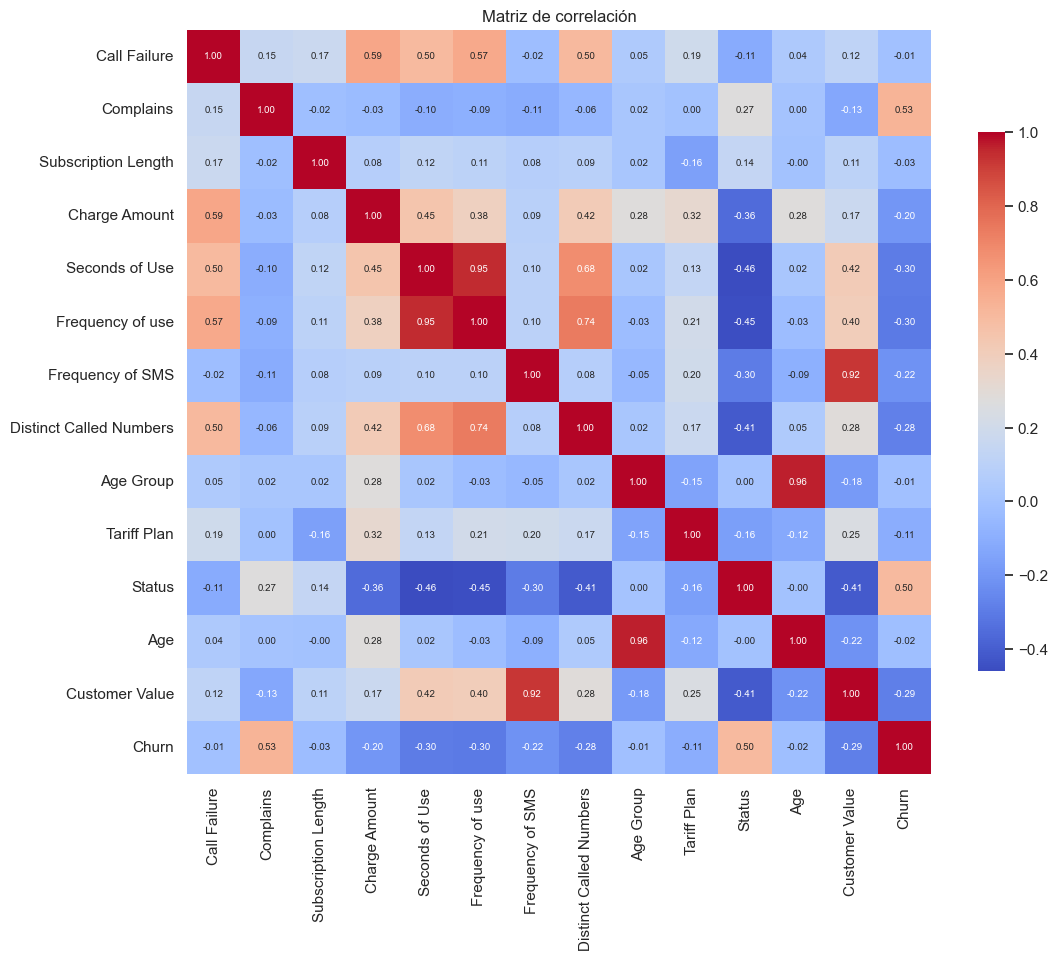

In [9]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f", square=True,
            annot_kws={"size": 7}, cbar_kws={"shrink": 0.7})
plt.title("Matriz de correlación")
plt.show()

In [10]:
df.corr()["Churn"].drop("Churn").sort_values()

Frequency of use          -0.303337
Seconds of Use            -0.298935
Customer Value            -0.289144
Distinct Called Numbers   -0.278867
Frequency of SMS          -0.220754
Charge Amount             -0.202305
Tariff Plan               -0.105853
Subscription Length       -0.032588
Age                       -0.017705
Age Group                 -0.014550
Call Failure              -0.008987
Status                     0.498976
Complains                  0.532053
Name: Churn, dtype: float64

**Qué dio**: con el churn las más correlacionadas son Complains (+0.53) y Status (+0.50); las de uso quedan negativas (Frequency of use -0.30, Seconds of Use -0.30, Customer Value -0.29). **Qué concluyo**: confirma todo lo del EDA con un número. `Age` y `Age Group` son la misma info (redundantes), así que me quedo con una sola para no duplicar señal.

### Separabilidad

Scatters 2D de pares de variables de uso, coloreados por churn.

- **Para qué**: ver si dos variables juntas separan visualmente las clases, o sea si el problema es linealmente separable en 2D.
- **Qué espero**: que los churners caigan en el rincón de uso bajo, pero con bastante solapamiento (no hay frontera limpia con dos variables).
- **Qué dio**: ver gráfico abajo.

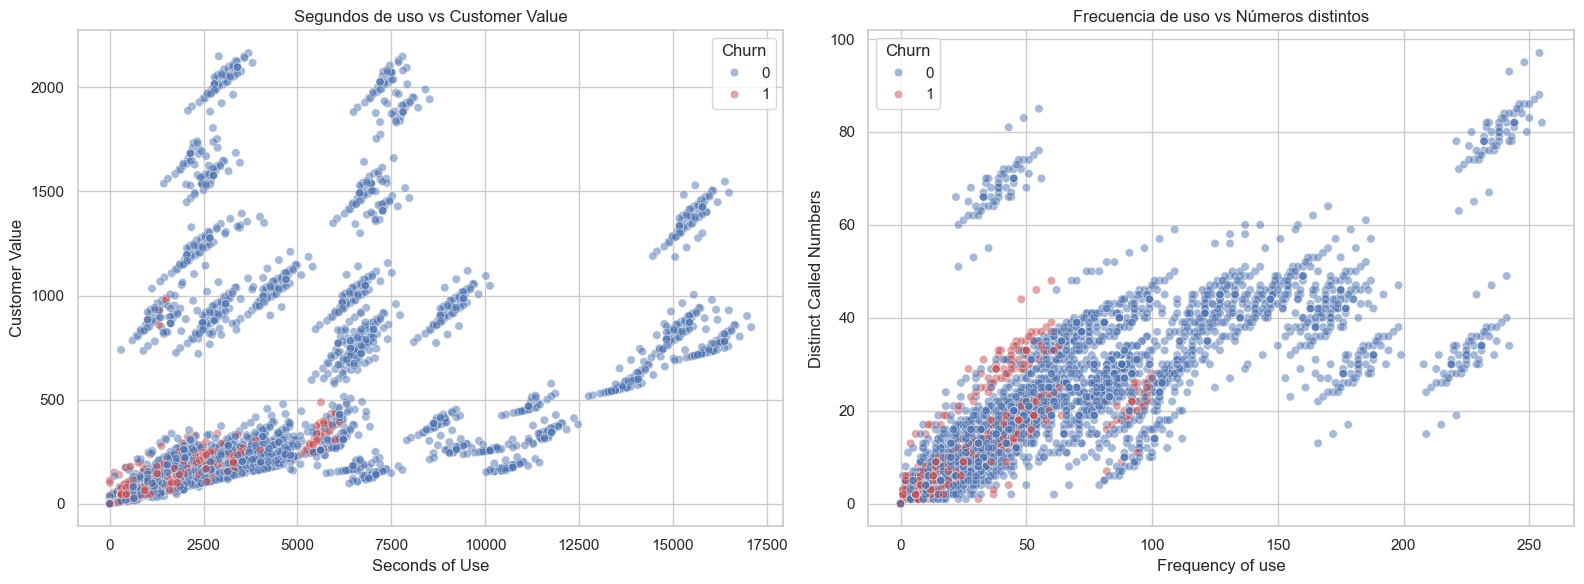

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.scatterplot(data=df, x="Seconds of Use", y="Customer Value", hue="Churn",
                palette=["#4c72b0", "#c44e52"], alpha=0.5, ax=axes[0])
axes[0].set_title("Segundos de uso vs Customer Value")
sns.scatterplot(data=df, x="Frequency of use", y="Distinct Called Numbers", hue="Churn",
                palette=["#4c72b0", "#c44e52"], alpha=0.5, ax=axes[1])
axes[1].set_title("Frecuencia de uso vs Números distintos")
plt.tight_layout()
plt.show()

**Qué dio**: los churners se agrupan abajo a la izquierda (uso y valor bajos) pero pisados por los que se quedan, sin frontera limpia. **Qué concluyo**: con dos variables no alcanza; va a hacer falta un modelo que combine varias y capture no linealidades.

### Vista 3D interactiva

Scatter 3D (segundos, frecuencia, customer value) coloreado por churn.

- **Para qué**: sumar una tercera dimensión de uso y rotar para ver si en 3D se separan mejor.
- **Qué espero**: que el churn quede algo más aislado al agregar el eje, pero igual con zona de mezcla.
- **Qué dio**: ver gráfico interactivo abajo.

In [12]:
fig = px.scatter_3d(df, x="Seconds of Use", y="Frequency of use", z="Customer Value",
                    color=df["Churn"].map({0: "no churn", 1: "churn"}), opacity=0.6,
                    color_discrete_map={"no churn": "#4c72b0", "churn": "#c44e52"},
                    title="Clientes en 3D según uso")
fig.update_traces(marker_size=3)
fig

**Qué dio** (3D): el grupo churn se ve un poco más definido en el rincón de uso bajo, pero sigue habiendo solapamiento. **Qué concluyo**: el uso bajo es la firma del churn pero ninguna combinación simple de variables lo separa solo; lo dejo para el modelo.

## 3. Preparación de los datos

Saco `Age`, hago split estratificado 80/20 y escalo las continuas con el scaler ajustado solo en train.

- **Para qué**: dejar los datos listos para modelar sin redundancia ni leakage. Saco `Age` por redundar con Age Group; estratifico para mantener el 16% de churn en ambas partes; escalo porque KNN y LogReg dependen de la escala.
- **Qué espero**: misma proporción de churn en train y test, y que el `fit` del scaler solo en train evite filtrar info del test.
- **Qué dio**: train 2520 x 12, test 630 x 12, churn 0.1571 en ambos.
- **Qué concluyo**: el split quedó balanceado y sin leakage, listo para entrenar.

In [13]:
df_model = df.drop(columns=["Age"])
X = df_model.drop(columns=["Churn"])
y = df_model["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_SEED)

a_escalar = ["Subscription Length", "Charge Amount", "Seconds of Use", "Frequency of use",
             "Frequency of SMS", "Distinct Called Numbers", "Age Group", "Customer Value", "Call Failure"]

scaler = StandardScaler()
X_train_s = X_train.copy()
X_test_s = X_test.copy()
X_train_s[a_escalar] = scaler.fit_transform(X_train[a_escalar])
X_test_s[a_escalar] = scaler.transform(X_test[a_escalar])

print("train:", X_train_s.shape, "| test:", X_test_s.shape)
print("churn train:", round(y_train.mean(), 4), "| churn test:", round(y_test.mean(), 4))

train: (2520, 12) | test: (630, 12)
churn train: 0.1571 | churn test: 0.1571


## 4. Modelado

Tres clasificadores (LogReg, KNN, Random Forest) con `class_weight="balanced"` donde aplica, comparados por F1 y recall de churn con CV de 5 folds.

- **Para qué**: comparar un modelo lineal (LogReg), uno por vecindad (KNN) y uno de ensamble de árboles (Random Forest) para ver cuál captura mejor el patrón. Uso CV de 5 folds para estimar el rendimiento sin tocar el test, y F1 de churn como criterio por el desbalance.
- **Qué espero**: que el Random Forest gane por capturar no linealidades e interacciones, y que la LogReg tenga recall alto pero baja precisión por el desbalance.
- **Qué dio**: en CV, RandomForest F1 0.83 (recall 0.79), KNN F1 0.75, LogReg F1 0.65 con recall 0.89.
- **Qué concluyo**: Random Forest es el candidato más equilibrado; la LogReg detecta casi todos los churners pero a costa de muchos falsos positivos.

In [14]:
models = {
    "LogReg": LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_SEED),
    "KNN": KNeighborsClassifier(n_neighbors=15),
    "RandomForest": RandomForestClassifier(n_estimators=300, class_weight="balanced",
                                           random_state=RANDOM_SEED),
}

cv_rows = []
for n, m in models.items():
    f1 = cross_val_score(m, X_train_s, y_train, cv=5, scoring="f1").mean()
    rec = cross_val_score(m, X_train_s, y_train, cv=5, scoring="recall").mean()
    cv_rows.append({"modelo": n, "cv_f1_churn": round(f1, 4), "cv_recall_churn": round(rec, 4)})
pd.DataFrame(cv_rows).sort_values("cv_f1_churn", ascending=False).reset_index(drop=True)

,modelo,cv_f1_churn,cv_recall_churn
0,RandomForest,0.8313,0.7932
1,KNN,0.7455,0.6668
2,LogReg,0.6537,0.8914


Entrenamos en train y evaluamos en el test que apartamos.

- **Para qué**: medir el rendimiento real de cada modelo en datos que no vio, con accuracy, precision, recall y F1 de churn.
- **Qué espero**: que el ranking de CV se sostenga y que la accuracy alta engañe (un 84% se logra diciendo "nadie se va").
- **Qué dio**: RandomForest F1 0.876 (precision 0.89, recall 0.86), KNN F1 0.787, LogReg F1 0.63 con accuracy 0.84 pero precision de churn 0.50.
- **Qué concluyo**: Random Forest es el mejor por F1 y se confirma la CV. La accuracy 0.84 de la LogReg muestra por qué no me guío por accuracy en datos desbalanceados.

In [15]:
rows = []
fitted = {}
for n, m in models.items():
    m.fit(X_train_s, y_train)
    fitted[n] = m
    pred = m.predict(X_test_s)
    rep = classification_report(y_test, pred, output_dict=True)
    rows.append({"modelo": n,
                 "accuracy": round(rep["accuracy"], 4),
                 "precision_churn": round(rep["1"]["precision"], 4),
                 "recall_churn": round(rep["1"]["recall"], 4),
                 "f1_churn": round(rep["1"]["f1-score"], 4)})
tabla = pd.DataFrame(rows).sort_values("f1_churn", ascending=False).reset_index(drop=True)
tabla

,modelo,accuracy,precision_churn,recall_churn,f1_churn
0,RandomForest,0.9619,0.8947,0.8586,0.8763
1,KNN,0.9397,0.8861,0.7071,0.7865
2,LogReg,0.8413,0.4971,0.8586,0.6296


## 5. Evaluación

Reporte de clasificación del mejor modelo (Random Forest) en el test.

- **Para qué**: ver el detalle final por clase del modelo elegido.
- **Qué espero**: recall de churn alto pero no perfecto, o sea que se escapen algunos churners.
- **Qué dio**: churn con precision 0.89, recall 0.86 y F1 0.88 sobre 99 casos; accuracy global 0.96.
- **Qué concluyo**: el modelo detecta 86 de cada 100 churners y cuando avisa acierta 9 de cada 10, un punto de partida sólido para retención.

In [16]:
best = tabla.iloc[0]["modelo"]
bm = fitted[best]
pred = bm.predict(X_test_s)
print("Mejor modelo:", best)
print(classification_report(y_test, pred, target_names=["no churn", "churn"]))

Mejor modelo: RandomForest
              precision    recall  f1-score   support

    no churn       0.97      0.98      0.98       531
       churn       0.89      0.86      0.88        99

    accuracy                           0.96       630
   macro avg       0.93      0.92      0.93       630
weighted avg       0.96      0.96      0.96       630



Matriz de confusión del Random Forest.

- **Para qué**: ver el desglose de aciertos y errores; en churn lo que más duele son los falsos negativos (churners que no detecto y por lo tanto no retengo).
- **Qué espero**: pocos falsos negativos, acorde al recall 0.86.
- **Qué dio**: ver gráfico abajo; sobre 99 churners reales detecta 85 y se le escapan 14, con ~10 falsos positivos.
- **Qué concluyo**: el error principal son esos 14 churners no detectados; si retención tiene cupo, bajaría el umbral para ganar recall aun perdiendo algo de precisión.

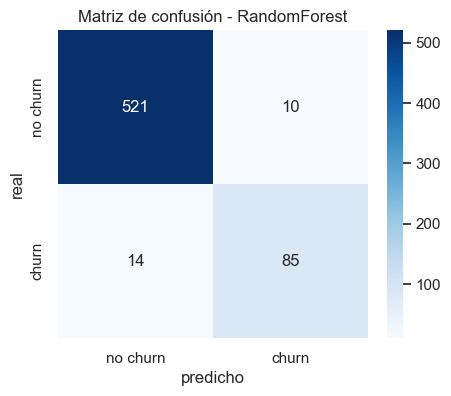

In [17]:
cm = confusion_matrix(y_test, pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["no churn", "churn"], yticklabels=["no churn", "churn"])
plt.title(f"Matriz de confusión - {best}")
plt.ylabel("real"); plt.xlabel("predicho")
plt.show()

Importancia de variables del Random Forest.

- **Para qué**: ver en qué variables se apoya el modelo para decidir, y chequear que coincida con lo que vi en el EDA.
- **Qué espero**: que Complains, Status y las de uso (Seconds of Use, Frequency of use, Customer Value) estén arriba, y abajo Age Group, Tariff Plan y Subscription Length.
- **Qué dio**: ver gráfico abajo; arriba quedan las variables de uso junto con Complains y Status, y al fondo las demográficas y de plan.
- **Qué concluyo**: el modelo usa las mismas señales que detectó el EDA, así que sus predicciones son interpretables y accionables para el negocio.

/var/folders/pp/2w01y9pd6px1lfx6rs9vs5p00000gp/T/ipykernel_99774/3188413171.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=imp.values, y=imp.index, palette="viridis")


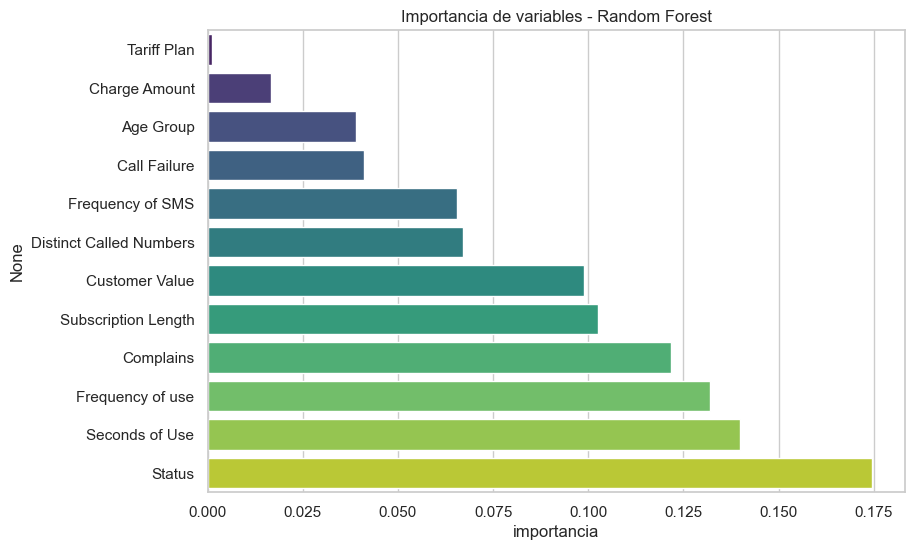

In [18]:
imp = pd.Series(fitted["RandomForest"].feature_importances_,
                index=X_train_s.columns).sort_values()
plt.figure(figsize=(9, 6))
sns.barplot(x=imp.values, y=imp.index, palette="viridis")
plt.title("Importancia de variables - Random Forest")
plt.xlabel("importancia")
plt.show()

## 6. Conclusiones

El que se va se queja, se inactiva y baja su uso. Random Forest fue el mejor por F1. Evaluar por F1 y no por accuracy fue clave (decir "nadie se va" ya da ~84%). En producción: correr el modelo sobre los activos y darle a retención la lista ordenada por probabilidad de churn.